In [17]:
using Revise
using PVlib

using HTTP
using JSON
using DataFrames
using Dates
using CSV
using Plots
using Statistics
using LinearAlgebra
using TimeZones

using Optim
using Zygote
using FiniteDiff
using ForwardDiff

In [18]:
latitude = 35.95
longitude = -75.125

api_key = "E52b7mqeTWLigj2xF5Bn4n6Mm87ecm5LFFeYh4US" # from NLR
email = "jtgrasb@sandia.gov"

start_monthday=(1, 1)
end_monthday=(1, 1)

weather_data = get_meteorological_data_nsrdb(latitude, longitude, api_key, email, start_monthday, end_monthday, false)

println(weather_data[12])

WeatherSample
────────────
time               │ 2019-01-01T11:00:00-05:00
ghi                │ 236.0
dni                │ 98.0
dhi                │ 186.0
temp_air           │ 16.2
temp_dew           │ 15.8
relative_humidity  │ missing
pressure           │ 1016.0
wind_speed         │ 5.9
wind_direction     │ 250.0
albedo             │ 0.01



In [19]:
latitude = 35.95
longitude = -75.125
altitude = 0.0

api_key = "E52b7mqeTWLigj2xF5Bn4n6Mm87ecm5LFFeYh4US" # from NLR
email = "jtgrasb@sandia.gov"

start_monthday=(1, 1)
end_monthday=(1, 1)

number_of_panels = 1
surface_azimuth = 180.0
surface_tilt = latitude

# try zygote one function at a time
weather_data = get_meteorological_data_nsrdb(latitude, longitude, api_key, email, start_monthday, end_monthday, false)

# area of 0.343 m^2, 9 cells per column with 4 columns, 0.526 x 0.652 m
module_name = "Kyocera Solar KC40T [2008 (E)]" #"Canadian Solar CS5P-220M [ 2009]" 
inverter_name = "Enphase Energy Inc : M175-24-208-Sxx [208V]" #"ABB: MICRO-0.25-I-OUTD-US-208 [208V]" # 175 W is well above max power needed

pv_module = read_solar_module(module_name)
pv_inverter = read_solar_inverter(inverter_name);

In [20]:
# testing panel tilt azimuth with Zygote

function panel_tilt_azimuth_zygote(
    motion::AbstractMatrix{<:Real},
    install_tilt_deg::Real = 0.0,
    install_azimuth_deg::Real = 0.0,
    yaw_offset_deg::Real = 0.0,
)
    roll = motion[:, 4]
    pitch = motion[:, 5]
    yaw = motion[:, 6] .+ deg2rad(yaw_offset_deg)

    β = deg2rad(install_tilt_deg)
    γ = deg2rad(install_azimuth_deg)

    n0x = sin(β) * sin(γ)
    n0y = sin(β) * cos(γ)
    n0z = cos(β)

    cy = cos.(yaw)
    sy = sin.(yaw)
    cp = cos.(pitch)
    sp = sin.(pitch)
    cr = cos.(roll)
    sr = sin.(roll)

    nx = (cy .* cp) .* n0x .+
         (cy .* sp .* sr .- sy .* cr) .* n0y .+
         (cy .* sp .* cr .+ sy .* sr) .* n0z

    ny = (sy .* cp) .* n0x .+
         (sy .* sp .* sr .+ cy .* cr) .* n0y .+
         (sy .* sp .* cr .- cy .* sr) .* n0z

    nz = (-sp) .* n0x .+
         (cp .* sr) .* n0y .+
         (cp .* cr) .* n0z

    nh = sqrt.(nx.^2 .+ ny.^2)
    tilt = atan.(nh, PVlib.pv_smooth_abs.(nz))
    azimuth = atan.(nx, ny)   # unwrapped

    return rad2deg.(tilt), rad2deg.(azimuth)
end

panel_tilt_azimuth_zygote (generic function with 4 methods)

In [21]:
# prescribe WEC motion in 6 degrees of freedom for 100 seconds
time = range(0, 500, 1001)
amplitude = [1.0, 0.1, 1.0, 0.2, 1.0, 0.2]
#amplitude = [0, 0, 0, 1.4, 0, 0]
period = 10 # seconds

ω = 2π / period
WEC_response = amplitude' .* sin.(ω .* time);


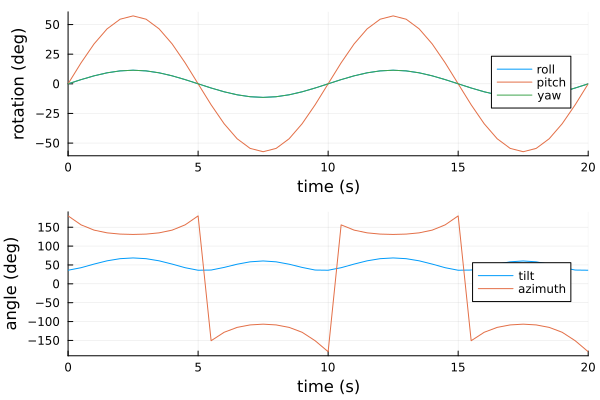

In [22]:
# translational degrees of freedom don't impact the orientation and tilt direction
installation_tilt = surface_tilt
installation_azimuth = 180.0
initial_yaw = 0.0
panel_tilt, panel_azimuth = panel_tilt_azimuth(WEC_response, installation_tilt, installation_azimuth, initial_yaw)
panel_tilt, panel_azimuth = panel_tilt_azimuth_zygote(WEC_response, installation_tilt, installation_azimuth, initial_yaw)

t = time                      # length N
x = WEC_response[:,1]; y = WEC_response[:,2]; z = WEC_response[:,3]
roll  = WEC_response[:,4]
pitch = WEC_response[:,5]
yaw   = WEC_response[:,6]

# 2) Rotational motions
p2 = plot(t, roll*180/pi,  label="roll",  xlabel="time (s)", ylabel="rotation (deg)",xlims=(0, 20),)
plot!(p2, t, pitch*180/pi, label="pitch")
plot!(p2, t, yaw*180/pi,   label="yaw")

# 3) Panel angles
p3 = plot(t, panel_tilt, label="tilt", xlabel="time (s)", ylabel="angle (deg)", xlims=(0, 20),)
plot!(p3, t, panel_azimuth,   label="azimuth")

plot(p2, p3, layout=(2,1), legend=:right)

In [23]:
# model for the albedo in ocean conditions
weather_data = get_meteorological_data_nsrdb(latitude, longitude, api_key, email, start_monthday, end_monthday, false)
sol_position = get_solar_position(latitude, longitude, altitude, weather_data[12])

# albedo from NSRDB generall not accurate over water, so use a model based on solar position and weather conditions for ocean surfaces
albedo = get_ocean_surface_albedo(weather_data[12], sol_position) 
println("Albedo: ", albedo)

#plot(getfield.(weather_data, :time), albedo, label="Albedo vs time", xlabel="time", ylabel="Albedo", legend=:topright)

Albedo: 0.06193415557060577


In [24]:
total_irradiance = get_total_irradiance(panel_tilt, panel_azimuth, weather_data[12], sol_position, albedo, time)

cell_temp_orig = sapm_cell_temperature(total_irradiance, weather_data[12]) 
cell_temp = rolling_average_sapm_cell_temperature(total_irradiance, weather_data[12]);

#plot(cell_temp_orig, :cell_temperature, label="Orig Cell Temperature")
#plot!(cell_temp, :cell_temperature, label="Rolling Average Cell Temperature")

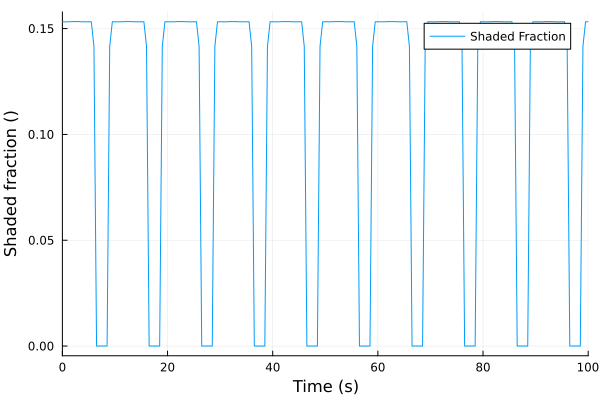

In [25]:
panel = Panel(0.526, 0.652) # panel dimensnions in meters (Kyocera Solar KC40T [2008 (E)])

# A box/beam above the panel with respect to the panel's local coordinates
obstacle = BoxObstacle(
    -1.0, 1.0,   # x-range
    -0.05, 0.05,     # y-range
    0.5, 0.6   # z-range
)

f_shade = get_shaded_fraction(sol_position, panel_tilt, panel_azimuth, panel, obstacle);

plot(time, f_shade, xlabel="Time (s)", ylabel="Shaded fraction ()", label="Shaded Fraction", legend=:topright, xlims=(0, 100))

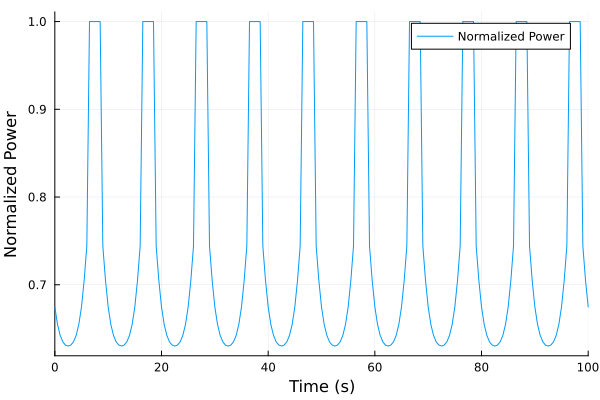

In [26]:
power_norm = get_power_norm(total_irradiance, f_shade, 9);

# Note that power normalization is approximately 1 when shaded fraction is below critical shading (1/n_cells_per_column).
plot(time, power_norm, xlabel="Time (s)", ylabel="Normalized Power", label="Normalized Power", legend=:topright, xlims=(0, 100))

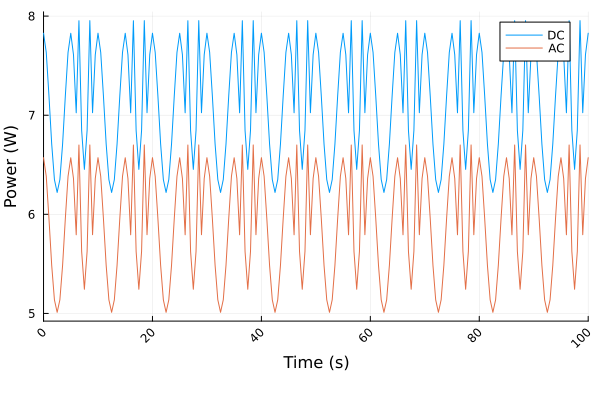

In [27]:
# assume the simulation is done for the 12th hour on this date
# in the future, we can allow time/date input to specify
sol_position = get_solar_position(latitude, longitude, altitude, weather_data[12])
total_irradiance = get_total_irradiance(panel_tilt, panel_azimuth, weather_data[12], sol_position, albedo, time)

cell_temp = rolling_average_sapm_cell_temperature(total_irradiance, weather_data[12]) 
effective_irradiance = sapm_effective_irradiance(total_irradiance, pv_module, sol_position, panel_tilt, panel_azimuth, altitude)

dc_components_shaded = sapm_dc_components_shaded(pv_module, effective_irradiance, cell_temp, power_norm)

ac_power = sandia_ac_power(pv_inverter, dc_components_shaded)

plot(dc_components_shaded, :p_mp, :elapsed, label="DC")
plot!(ac_power, :ac_power, :elapsed, label="AC", xlabel="Time (s)", ylabel="Power (W)", legend=:topright, xrotation = 45, bottom_margin=8Plots.mm, xlims=(0, 100))


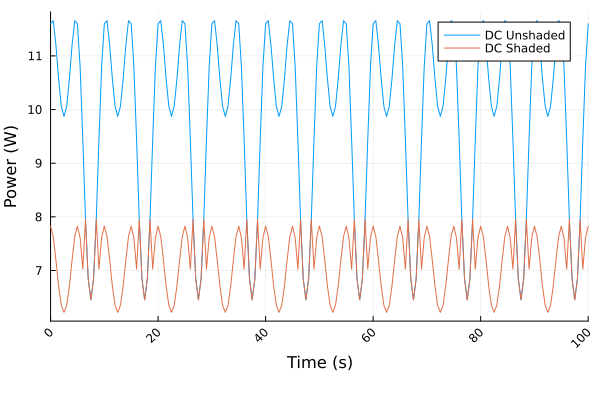

In [28]:
dc_components = sapm_dc_components(pv_module, effective_irradiance, cell_temp)

dc_components_shaded = sapm_dc_components_shaded(pv_module, effective_irradiance, cell_temp, power_norm)

plot(dc_components, :p_mp, :elapsed, label="DC Unshaded")
plot!(dc_components_shaded, :p_mp, :elapsed, label="DC Shaded", xlabel="Time (s)", ylabel="Power (W)", xrotation = 45, bottom_margin=8Plots.mm, xlims=(0, 100))
#plot!(time, 10*power_norm, label="Power normalization factor", legend=:topright, xlims=(0, 100))

In [29]:
# optimize the initial panel tilt to maximize average power using Zygote
# assume initial yaw is always the same

# create function that support initial tilt input
function dc_power_return(latitude, longitude, altitude, 
                        initial_tilt, initial_azimuth, weather_data, sol_position, 
                        pv_module, pv_inverter, WEC_response, panel, obstacle, 
                        n_cells_per_column, albedo, sim_time)
    
    panel_tilt, panel_azimuth = panel_tilt_azimuth_zygote(WEC_response, initial_tilt, initial_azimuth)

    total_irradiance = get_total_irradiance(panel_tilt, panel_azimuth, weather_data, sol_position, albedo, sim_time) 
    #cell_temp = rolling_average_sapm_cell_temperature(total_irradiance, weather_data)
    cell_temp = sapm_cell_temperature(total_irradiance, weather_data)

    effective_irradiance = sapm_effective_irradiance(total_irradiance, pv_module, sol_position, panel_tilt, panel_azimuth, altitude)

    #f_shade = get_shaded_fraction(sol_position, panel_tilt, panel_azimuth, panel, obstacle, nx=10, ny=10)
    #power_norm = get_power_norm(total_irradiance, f_shade, n_cells_per_column)

    dc_components_shaded = sapm_dc_components(pv_module, effective_irradiance, cell_temp) # , power_norm
    ac_power = sandia_ac_power(pv_inverter, dc_components_shaded)
    return getfield.(dc_components_shaded, :p_mp)
end

dc_power_return (generic function with 1 method)

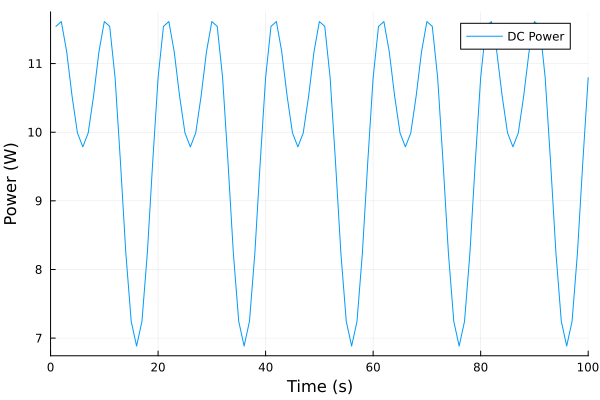

In [30]:
# location and installation details for pioneer
latitude = 35.95
longitude = -75.125
altitude = 0.0 # m
api_key = "E52b7mqeTWLigj2xF5Bn4n6Mm87ecm5LFFeYh4US" # from NLR
email = "jtgrasb@sandia.gov"
start_monthday=(1, 1)
end_monthday=(1, 1)
number_of_panels = 1
initial_azimuth = 180.0
initial_tilt = latitude
module_name = "Kyocera Solar KC40T [2008 (E)]" #"Canadian Solar CS5P-220M [ 2009]" 
inverter_name = "Enphase Energy Inc : M175-24-208-Sxx [208V]" #"ABB: MICRO-0.25-I-OUTD-US-208 [208V]" # 175 W is well above max power needed
pv_module = read_solar_module(module_name)
pv_inverter = read_solar_inverter(inverter_name);

# create example WEC resposne
time = range(0, 500, 1001)
amplitude = [1, 0.1, 1, 0.1, 1, 0.2]
period = 10 # seconds
ω = 2π / period
WEC_response = amplitude' .* sin.(ω .* time)

# installation characteristics
panel = Panel(0.526, 0.652) # panel dimensnions in meters (Kyocera Solar KC40T [2008 (E)])
# A box above the panel
obstacle = BoxObstacle(
    -0.5, 0.5,   # x-range
    -0.3, 0.3,     # y-range
    0.4, 0.5   # z-range
)
n_cells_per_column = 9

# import weather data, calculate solar position, and corresponding albedo
weather_data = get_meteorological_data_nsrdb(latitude, longitude, api_key, email, start_monthday, end_monthday, false)
weather_data = weather_data[12] # just use the 12th hour for this simulation
sol_position = get_solar_position(latitude, longitude, altitude, weather_data)
albedo = get_ocean_surface_albedo(weather_data, sol_position)

dc_power = dc_power_return(latitude, longitude, altitude, initial_tilt, initial_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)

plot(dc_power, label="DC Power", xlabel="Time (s)", ylabel="Power (W)", legend=:topright, xlims=(0, 100))

In [31]:
f2(tilt) = begin
    pt, pa = panel_tilt_azimuth_zygote(WEC_response, tilt, initial_azimuth)
    irr = get_total_irradiance(pt, pa, weather_data, sol_position, albedo, time)

    eff = sapm_effective_irradiance(irr, pv_module, sol_position, pt, pa, altitude)

    sum(getfield.(eff, :effective_irradiance))
end

Zygote.gradient(f2, initial_tilt)

(492.0184595430434,)

In [32]:
f1(tilt) = begin
    pt, pa = panel_tilt_azimuth_zygote(WEC_response, tilt, initial_azimuth)
    irr = get_total_irradiance(pt, pa, weather_data, sol_position, albedo, time)
    cell_temp = sapm_cell_temperature(irr, weather_data)
    effective_irradiance = sapm_effective_irradiance(irr, pv_module, sol_position, pt, pa, altitude)

    dc_components = sapm_dc_components(pv_module, effective_irradiance, cell_temp) # , power_norm
    ac_power = sandia_ac_power(pv_inverter, dc_components)
    #sum(getfield.(ac_power, :ac_power))   # adjust field if needed
    #ac_power = map(dc -> sandia_ac_power(pv_inverter, dc).ac_power, dc_components)
    #sum(ac_power)
    #sum(getfield.(dc_components, :p_mp))
    sum(getfield.(ac_power, :ac_power))
end

Zygote.gradient(f1, initial_tilt)

(21.042746899051533,)

In [33]:
function objective(latitude, longitude, altitude, 
                        installation_tilt, installation_azimuth, weather_data, sol_position, 
                        pv_module, pv_inverter, WEC_response, panel, obstacle, 
                        n_cells_per_column, albedo, sim_time)

    avg_power = mean(dc_power_return(latitude, longitude, altitude, 
                        installation_tilt, installation_azimuth, weather_data, sol_position, 
                        pv_module, pv_inverter, WEC_response, panel, obstacle, 
                        n_cells_per_column, albedo, sim_time))
    return -avg_power
end

installation_tilt = latitude
installation_azimuth = 180.0

check_mean_power = objective(latitude, longitude, altitude, installation_tilt, installation_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)
println("Mean power for installation tilt: ", -check_mean_power)

mean_power = orientation -> objective(latitude, longitude, altitude, orientation[1], installation_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)

Mean power for installation tilt: 9.903781426799881


#2 (generic function with 1 method)

In [34]:
fd_using_fd = FiniteDiff.finite_difference_derivative(mean_power, initial_tilt, Val(:central))

-0.021656896643011018

In [35]:
ad_using_fd = ForwardDiff.derivative(mean_power, initial_tilt)

-0.021656896644800867

In [36]:
# Optimize installation tilt

function g!(G, orientation)
    ForwardDiff.gradient!(G, mean_power, orientation)
end

tilt0 = [surface_tilt]
tilt0_lower = [0.0]
tilt0_upper = [90.0]
res = optimize(mean_power, g!, tilt0_lower, tilt0_upper, tilt0, Fminbox(BFGS()))

println("Optimal initial tilt: ", res.minimizer[1])
println("Maximum mean power: ", -res.minimum)

Optimal initial tilt: 46.041143298150516
Maximum mean power: 10.012294302701676


In [48]:
# optimize installation tilt and azimuth
mean_power = orientation -> objective(latitude, longitude, altitude, orientation[1], orientation[2], weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)

function g!(G, orientation)
    ForwardDiff.gradient!(G, mean_power, orientation)
end

x0 = [surface_tilt, 180.0]
x0 = [90.0, 100.0]
lower = [0.0, 0.0]
upper = [90.0, 360.0]

res = optimize(mean_power, g!, lower, upper, x0, Fminbox(BFGS()))

println("Optimal installation tilt: ", res.minimizer[1])
println("Optimal installation azimuth: ", res.minimizer[2])
println("Maximum mean power: ", -res.minimum)

Optimal installation tilt: 87.30581663450604
Optimal installation azimuth: 135.18488532178804
Maximum mean power: 10.373372408457165


┌ Warning: Initial position cannot be on the boundary of the box. Moving elements to the interior.
│ Element indices affected: [1]
└ @ Optim C:\Users\jtgrasb\.julia\packages\Optim\7krni\src\multivariate\solvers\constrained\fminbox.jl:441


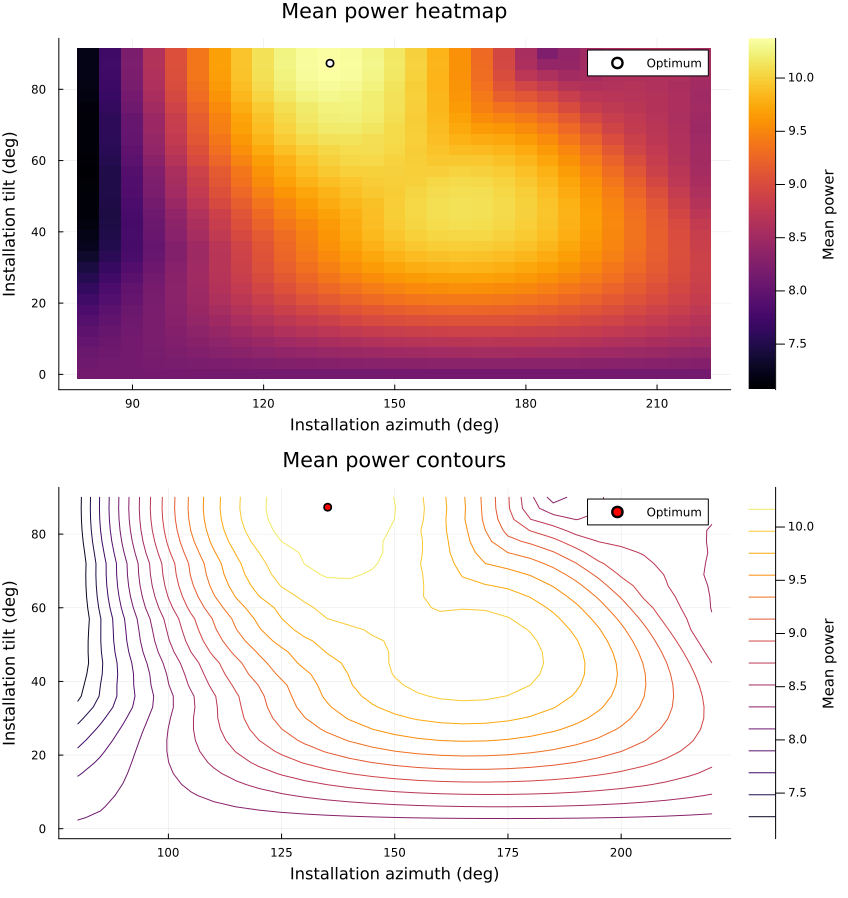

In [49]:
tilt_range = 0.0:3.0:90.0
azimuth_range = 80.0:5.0:220.0

power_grid = [
    -objective(
        latitude, longitude, altitude,
        tilt, azimuth,
        weather_data, sol_position,
        pv_module, pv_inverter, WEC_response,
        panel, obstacle, n_cells_per_column,
        albedo, time
    )
    for tilt in tilt_range, azimuth in azimuth_range
]

p1 = heatmap(
    azimuth_range,
    tilt_range,
    power_grid,
    xlabel="Installation azimuth (deg)",
    ylabel="Installation tilt (deg)",
    colorbar_title="Mean power",
    title="Mean power heatmap",
    legend=:topright,
)

scatter!(p1, [res.minimizer[2]], [res.minimizer[1]], color=:white, markerstrokecolor=:black, label="Optimum")

p2 = contour(
    azimuth_range,
    tilt_range,
    power_grid,
    xlabel="Installation azimuth (deg)",
    ylabel="Installation tilt (deg)",
    title="Mean power contours",
    levels=15,
    colorbar_title="Mean power",
    legend=:topright,
)

scatter!(p2, [res.minimizer[2]], [res.minimizer[1]], color=:red, markerstrokecolor=:black, label="Optimum")

plot(p1, p2, layout=(2,1), size=(850,900))

In [39]:
mean_power = orientation -> objective(latitude, longitude, altitude, orientation[1], installation_azimuth, weather_data, sol_position, pv_module, pv_inverter, WEC_response, panel, obstacle, n_cells_per_column, albedo, time)

g = Zygote.gradient(mean_power, [initial_tilt])[1]
# better for more inputs and less outputs (objective and constraints)
# SNOW.jl helps with sparsity and coloring for efficient optimization
# move stuff out of the optimization loop when possible!
# literature review will help figure out how to word paper
# COTS cost per mass - Kevin will add in function
# Discrete variable can be smoothed or pareto front for each module
# Flow lab has some functions for turning on and off optimization variables
# Kevin will add in latin hypercube for initialization

println("Gradient at initial tilt using Zygote: ", g)

Gradient at initial tilt using Zygote: [-0.02165689664480094]
